In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import source

In [3]:
importlib.reload(source)

<module 'source' from 'c:\\Users\\HP\\Documents\\Keng\\Projects\\MyProject\\RealProject\\something\\source.py'>

In [4]:
from source import PriceSimulator, GreeksEngine, HedgingBot

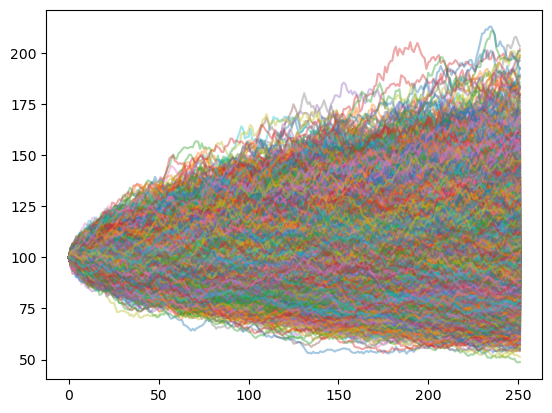

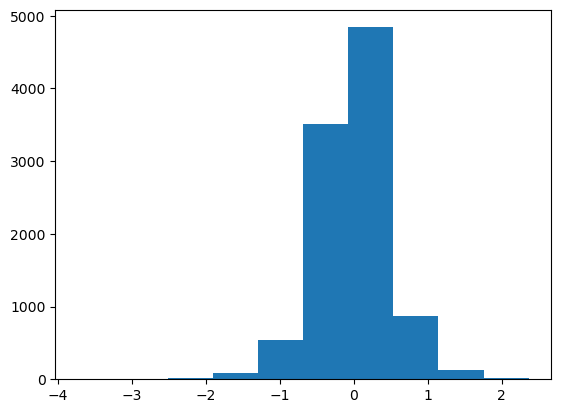

In [5]:
T = 1
n = 252
r = 0.03
dt = T / (n-1)

sim = PriceSimulator(100, 0.05, 0.2, T, n, 10_000, "GBM")
paths = sim.simulate()

greek = GreeksEngine("Call", 110, r, 0.2, 1)
premium = greek.price(100, 0)

# hedging_errors_all_paths = []
# final_PnL_all_paths = []

# for i in range(len(paths)):
#     each_path = paths[i]
#     port_values_per_path = []
#     BS_price_per_path = []
#     bot = HedgingBot(premium)

#     for j in range(len(each_path)):
#         S = each_path[j]
#         t = j * dt 
#         delta_t = greek.delta_compute(S, t)
#         bot.hedge(delta_t, S)
#         port_values = bot.portfolio_values(S)
#         port_values_per_path.append(port_values)
#         BS_price = greek.price(S, t)
#         BS_price_per_path.append(BS_price)

#     port_values_per_path = np.array(port_values_per_path)
#     BS_price_per_path = np.array(BS_price_per_path)

#     hedging_errors_per_path = port_values_per_path - BS_price_per_path
#     hedging_errors_all_paths.append(hedging_errors_per_path)
#     final_PnL_per_path = hedging_errors_per_path[-1]
#     final_PnL_all_paths.append(final_PnL_per_path)

t = np.linspace(0, T, n)
all_deltas = greek.compute_all_deltas(paths, t)
delta_diff = all_deltas[:, 1:] - all_deltas[:, :-1]
# prepend initial position change (from 0 to delta_0)
initial_diff = all_deltas[:, 0:1] # shape (m, 1)
delta_diff = np.hstack([initial_diff, delta_diff]) # shape (m, n)
cash_changes = -delta_diff * paths
time_remaining = T - t
total_cash = premium * np.exp(r * T) + (cash_changes * np.exp(r * time_remaining)).sum(axis=1)
payoff = np.maximum(paths[:, -1] - greek.K, 0)
final_PnL = total_cash + all_deltas[:, -1] * paths[:, -1] - payoff

# Plotting paths
plt.figure()
plt.plot(paths.T, alpha=0.4)
plt.show()

plt.figure()
plt.hist(final_PnL)
plt.show()

In [11]:
print(f"mean: {final_PnL.mean()}")
print(f"std: {final_PnL.std()}")

mean: 0.001065565022289695
std: 0.47123608202008227
